In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import warnings
import kDBCV
import scipy
from umap import UMAP
import hdbscan
import matplotlib.patheffects as patheffects
import plotly.express as px
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats

warnings.filterwarnings("ignore")

C:\Users\filipe.figueira\OneDrive - SEF-MG\Área de Trabalho\MBA\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Carrega o banco de dados:

df = pd.read_csv('dados_pre_processados_8708_com_clusters.csv')
ncms = pd.read_csv('ncms_csv.csv', sep = ';', encoding = 'latin1')

In [3]:
# Funções auxiliares para as modelagens:

def carrega_embeddings(caminho_embeddings: str, indice: set, variavel: str) -> np.ndarray:
    """
    Carregas os embeddings salvos em formato .parquet, em que há, neste banco de dados, uma variável de índice.

    Args:
        caminho_embeddings (str): A pasta de origem em que o embedding está salvo;
        indice (str): O nome da variável de índice;
        variavel (str): O nome da variável que foi transformada em embedding.

    Returns:
        np.ndarray: Uma matriz de tamanho 1 x dimensão do embedding, contendo os embeddings carregados
    """
    
    nome_variavel_embedding = f'embedding_{variavel}'
    tbl = pq.read_table(caminho_embeddings, columns = ['idx', nome_variavel_embedding]).to_pandas()
    tbl = tbl[tbl['idx'].isin(indice)].sort_values('idx')
    return np.vstack(tbl[nome_variavel_embedding].apply(np.array)).astype(np.float32)

def gerar_amostra(dados: np.ndarray, rotulos: np.ndarray, tamanho_amostra: int, semente_aleatoria: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Seleciona uma amostra estratificada e reprodutível de um conjunto de dados e seus rótulos.
    A estratificação mantém a proporção de outliers (rótulo -1) e não-outliers igual à do dataset.

    Args:
        dados (np.ndarray): O array de dados (vetores de características, ex: X_umap);
        rotulos (np.ndarray): O array com os rótulos de cluster correspondentes;
        tamanho_amostra (int): O número de pontos desejado na amostra;
        semente_aleatoria (int): A semente para o gerador de números aleatórios.

    Returns:
        tuple[np.ndarray, np.ndarray]: (dados_da_amostra, rotulos_da_amostra).
    """
    n_total_pontos = len(rotulos)

    # Caso o dataset seja menor ou igual ao tamanho da amostra, retorna o dataset completo
    if n_total_pontos <= tamanho_amostra:
        return dados, rotulos

    rng = np.random.default_rng(semente_aleatoria)

    # Máscaras para outliers e não-outliers
    mask_outliers = (rotulos == -1)
    mask_inliers = ~mask_outliers

    n_outliers = mask_outliers.sum()
    n_inliers = mask_inliers.sum()

    # Proporção de outliers no dataset
    prop_outliers = n_outliers / n_total_pontos

    # Número de outliers e inliers a sortear na amostra
    n_outliers_amostra = int(round(prop_outliers * tamanho_amostra))
    n_inliers_amostra = tamanho_amostra - n_outliers_amostra

    # Sorteio estratificado sem reposição
    idx_outliers = rng.choice(np.where(mask_outliers)[0], size = min(n_outliers_amostra, n_outliers), replace = False)
    idx_inliers = rng.choice(np.where(mask_inliers)[0], size = min(n_inliers_amostra, n_inliers), replace = False)

    # Junta e embaralha os índices
    idx_final = np.concatenate([idx_outliers, idx_inliers])
    rng.shuffle(idx_final)

    return dados[idx_final], rotulos[idx_final]

# Box-plot de log_vuncom:

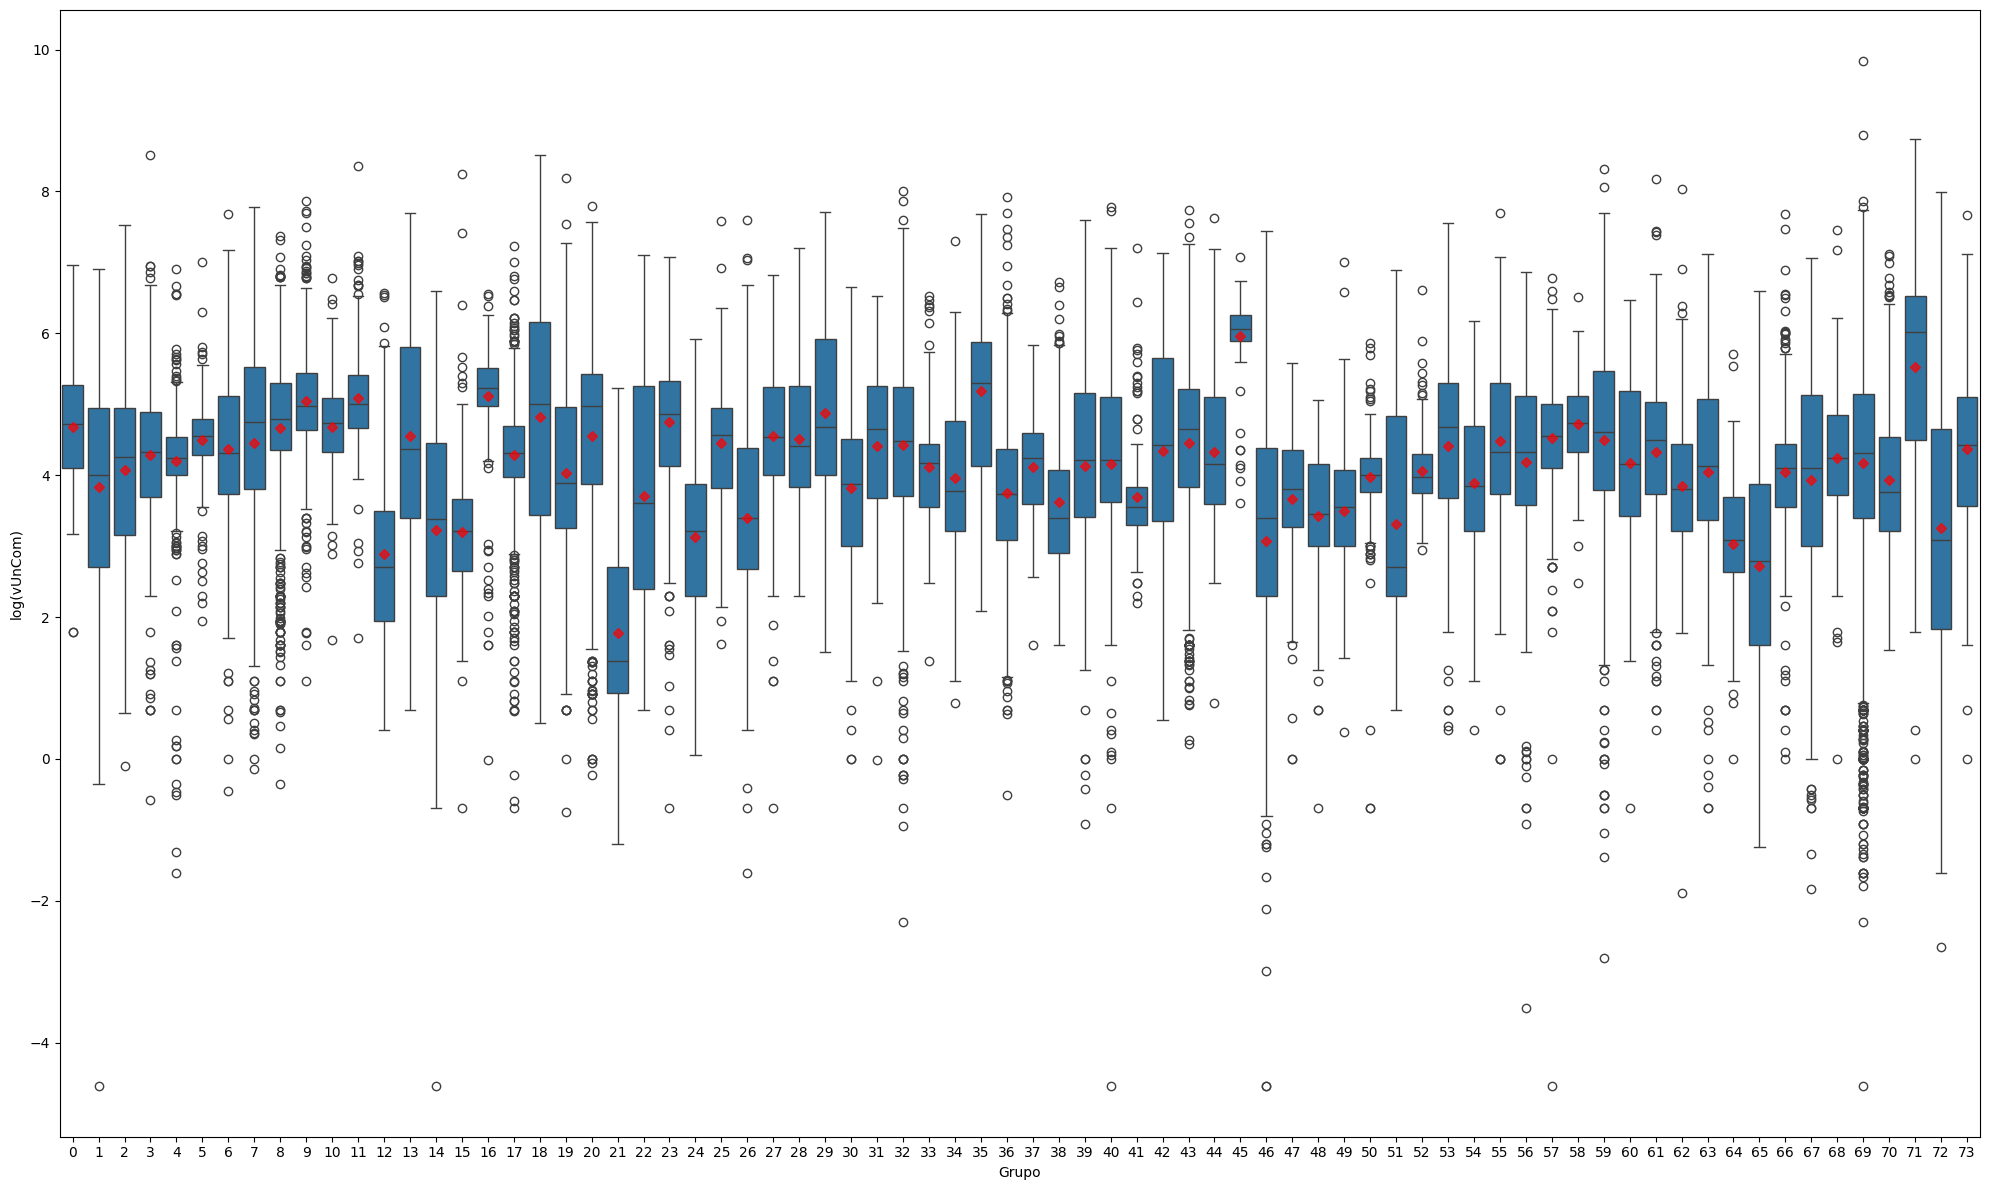

In [5]:
plt.figure(figsize=(20, 12))

sns.boxplot(
    data = df[(df.clusters.notna()) & (df.clusters != -1)], 
    x = 'clusters', 
    y = 'log_vuncom',
    showmeans = True,
    meanprops = {
        "marker": "D",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
        "markersize": "5",
        "alpha": 0.7})

plt.xlabel('Grupo')
plt.ylabel('log(vUnCom)')
plt.tight_layout()

plt.savefig('log_vuncom_clusters.png', dpi = 300, format = 'png')

# VC por Cluster:

In [4]:
# Seleciona as variáveis para o vetor de características:
coluna_texto_atual = 'T4'
pasta_embeddings = 'embeddings_parquet_multilingual'
n_neighbors = 30
min_dist = 0.0
n_components = 50
min_cluster_size = 50
min_samples = 80

# Define o subgrupo:
indices = set(df['idx'].values)
    
# Define os embeddings:
caminho_arquivo_embedding = f'{pasta_embeddings}/embedding_{coluna_texto_atual}_8708.parquet'
    
# Carrega os embeddings:
embedding_texto = carrega_embeddings(caminho_arquivo_embedding, indices, coluna_texto_atual)

X = embedding_texto.astype(np.float32)   

# UMAP:
umap_model = UMAP(n_neighbors = n_neighbors, min_dist = min_dist, n_components = n_components, metric = 'cosine', low_memory = True, random_state = 1234)
X_umap = umap_model.fit_transform(X)
rotulos = df.clusters

# Calcula o VC Score
score_dbcv, ind_clust_score_array = kDBCV.DBCV_score(X_umap, rotulos, ind_clust_scores = True)

# Monta um Data Frame para salvar o VC:
contagem_itens = df[df['clusters'] != -1]['clusters'].value_counts().sort_index()
df_vc_scores = pd.DataFrame(contagem_itens)
df_vc_scores.columns = ['qtd_itens']
df_vc_scores['VC_Score'] = ind_clust_score_array
df_vc_scores = df_vc_scores.reset_index()
df_vc_scores = df_vc_scores.rename(columns={'clusters': 'cluster'})
df_vc_scores_ordenado = df_vc_scores.sort_values(by = 'VC_Score', ascending = False)

# Salva o resultado

df_vc_scores_ordenado.to_csv('vc_score.csv')

# Gráfico UMAP 2D por cluster:

In [7]:
# UMAP:
umap_model = UMAP(n_neighbors = n_neighbors, min_dist = min_dist, n_components = 2, metric = 'cosine', low_memory = True, random_state = 1234)
X_umap_2d = umap_model.fit_transform(X)
df_plot = pd.DataFrame(X_umap_2d, columns = ['UMAP_1', 'UMAP_2'])
df_plot['cluster'] = rotulos

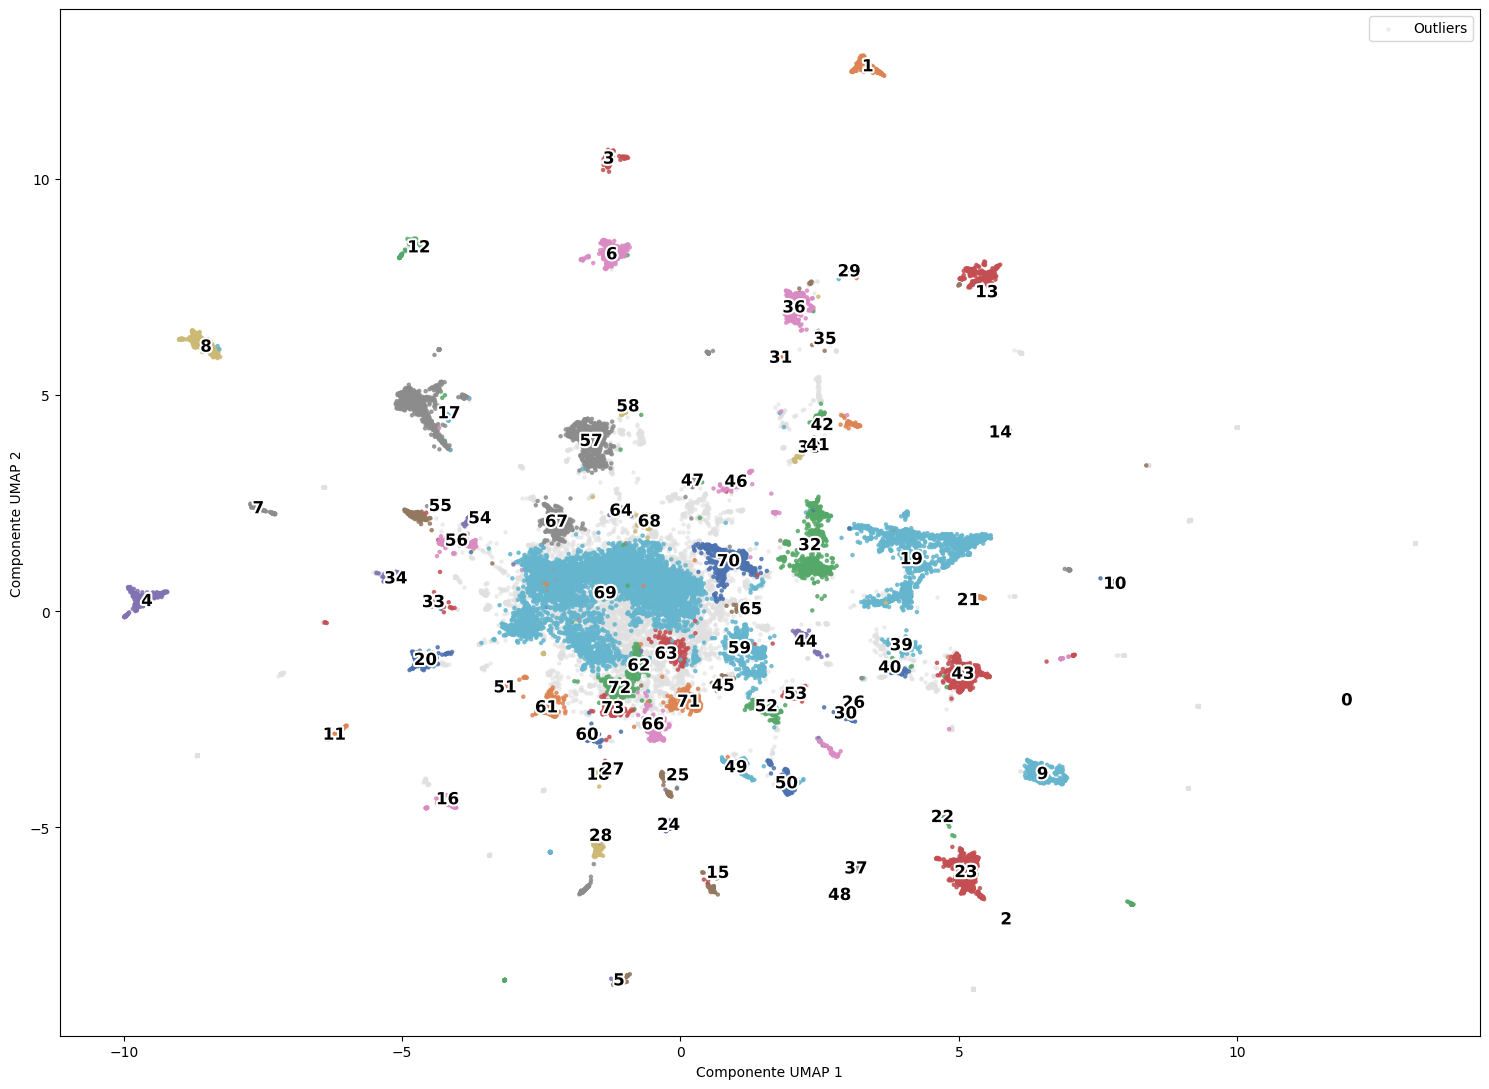

In [8]:
plt.figure(figsize = (15, 11))

outliers = df_plot[df_plot.cluster == -1]
clusterizados = df_plot[df_plot.cluster != -1]
centroides = clusterizados.groupby('cluster')[['UMAP_1', 'UMAP_2']].mean()

plt.scatter(x = outliers['UMAP_1'], y = outliers['UMAP_2'], color = '#e0e0e0',
            s = 5, alpha = 0.5, label = 'Outliers')

num_clusters = clusterizados['cluster'].nunique()
paleta_cores = sns.color_palette('deep', n_colors = num_clusters)
mapa_de_cores = dict(zip(sorted(clusterizados['cluster'].unique()), paleta_cores))
cores_dos_pontos = clusterizados['cluster'].map(mapa_de_cores)

plt.scatter(x = clusterizados['UMAP_1'], y = clusterizados['UMAP_2'], c = cores_dos_pontos, s = 5, alpha = 0.8)

plt.legend()

for cluster_id, center in centroides.iterrows():
    plt.text(x = center['UMAP_1'], y = center['UMAP_2'], s = str(int(cluster_id)),
             fontsize = 12, fontweight = 'bold', color = 'black', ha = 'center', va = 'center',
             path_effects = [patheffects.withStroke(linewidth = 3, foreground = 'white')])

plt.xlabel('Componente UMAP 1')
plt.ylabel('Componente UMAP 2')
plt.tight_layout()

plt.savefig('umap_2d_clusters_8708.png', dpi = 300)
plt.show()

# Gráfico UMAP 2D por VC:

In [9]:
# Inserindo a coluna de VC_Score em df_plot

df_plot = pd.merge(df_plot, df_vc_scores_ordenado[['cluster', 'VC_Score']], on = 'cluster', how = 'left')

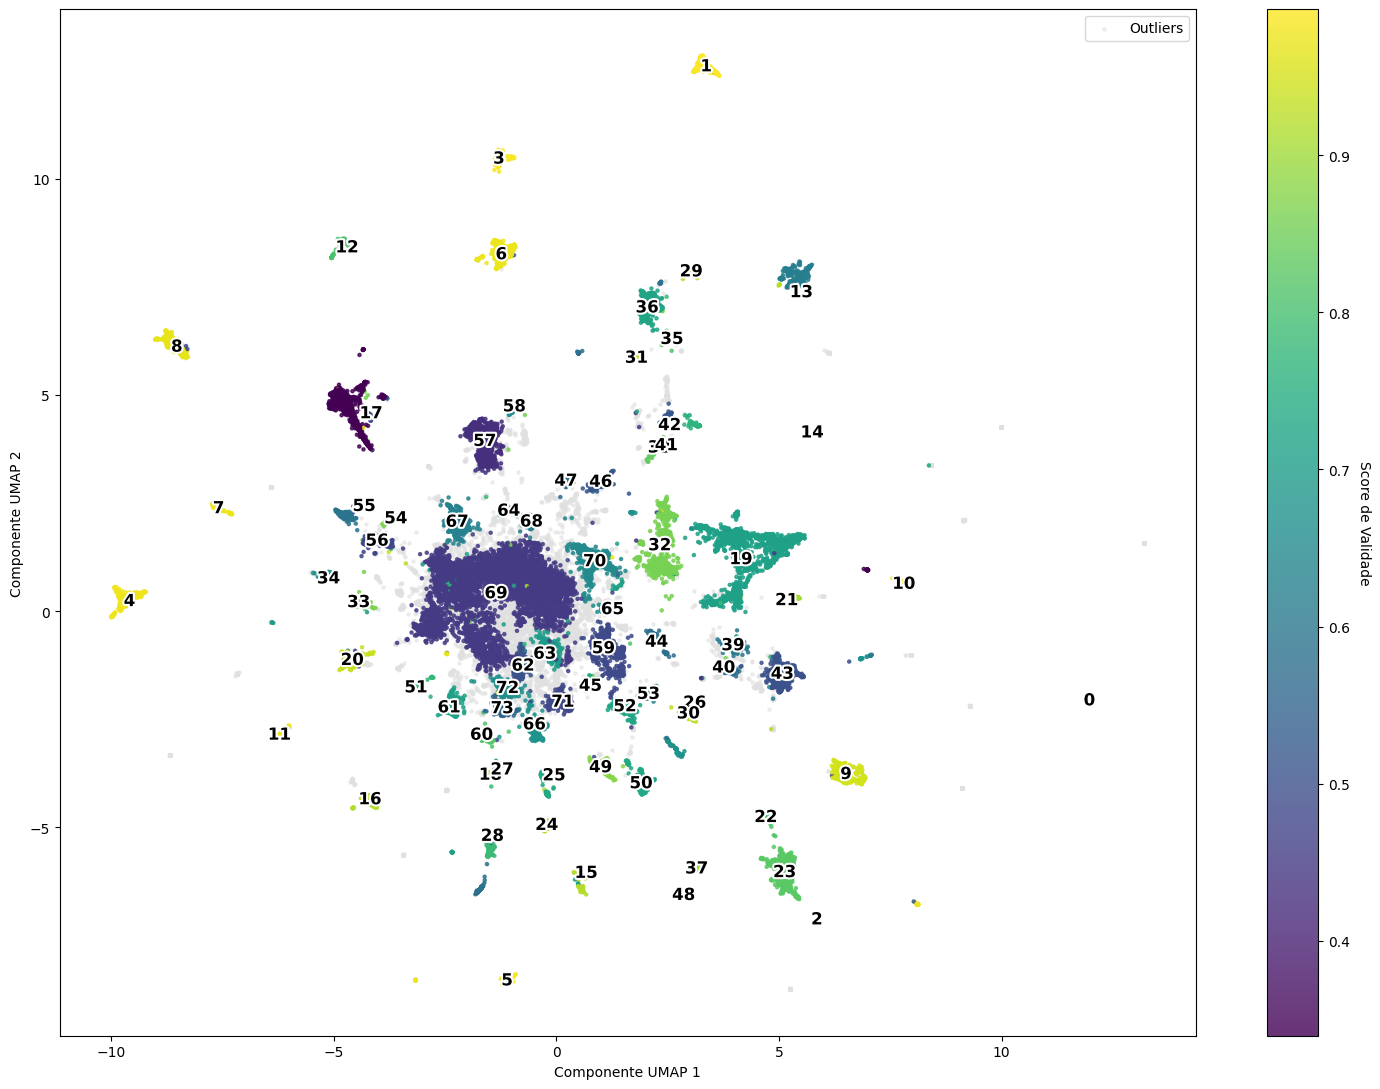

In [10]:
plt.figure(figsize=(15, 11))

outliers = df_plot[df_plot.cluster == -1]
clusterizados = df_plot[df_plot.cluster != -1]
centroides = clusterizados.groupby('cluster')[['UMAP_1', 'UMAP_2']].mean()

plt.scatter(x = outliers['UMAP_1'], y = outliers['UMAP_2'], 
            color = '#e0e0e0', s = 5, alpha = 0.5, label = 'Outliers')

scatter_plot = plt.scatter(
    x = clusterizados['UMAP_1'], y = clusterizados['UMAP_2'],
    c = clusterizados['VC_Score'], cmap = 'viridis', s = 5, alpha = 0.8)

cbar = plt.colorbar(scatter_plot)
cbar.set_label('Score de Validade', rotation = 270, labelpad = 15)

plt.legend()

for cluster_id, center in centroides.iterrows():
    plt.text(x = center['UMAP_1'], y = center['UMAP_2'], s = str(int(cluster_id)),
             fontsize = 12, fontweight = 'bold', color = 'black', ha = 'center', va = 'center',
             path_effects = [patheffects.withStroke(linewidth = 3, foreground = 'white')])

plt.xlabel('Componente UMAP 1')
plt.ylabel('Componente UMAP 2')
plt.tight_layout()

plt.savefig('umap_2d_clusters_8708_por_vc.png', dpi = 300)
plt.show()

# Gráfico UMAP 3D:

In [11]:
# UMAP:
umap_model = UMAP(n_neighbors = n_neighbors, min_dist = min_dist, n_components = 3, metric = 'cosine', low_memory = True, random_state = 1234)
X_umap_3d = umap_model.fit_transform(X)
df_plot_3d = pd.DataFrame(X_umap_3d, columns = ['UMAP_1', 'UMAP_2', 'UMAP_3'])
df_plot_3d['cluster'] = rotulos
df_plot_3d['Grupo'] = df_plot_3d['cluster'].astype(str)
df_plot_3d.loc[df_plot_3d['cluster'] == -1, 'Grupo'] = 'Outlier'

In [12]:
fig = px.scatter_3d(df_plot_3d, x = 'UMAP_1', y = 'UMAP_2', z = 'UMAP_3', 
                    color = 'Grupo', color_discrete_map = {'Outlier': 'lightgrey'}, hover_name = 'Grupo')

fig.update_layout(
    title = 'Visualização UMAP 3D dos Grupos Gerados',
    margin = dict(l = 0, r = 0, b = 0, t = 40))

fig.update_traces(marker = dict(size = 2, opacity = 0.8))

fig.write_html("umap_3d_clusters.html")

# Análise de 50 itens aleatórios de cada cluster:

In [13]:
df_vc_scores_ordenado.rename(columns = {'cluster':'clusters'}, inplace = True)
df = pd.merge(df, df_vc_scores_ordenado[['clusters', 'VC_Score']], on = 'clusters', how = 'left')

In [14]:
# Sorteando x itens aleatórios de cada cluster para analisar:

qtd_itens = 50 # Quantos itens quero analisar de cada cluster

tamanho_total_clusters = df['clusters'].value_counts().to_dict()
df_clusterizados = df[df['clusters'] != -1].copy()

amostras_df = df_clusterizados.groupby('clusters').apply(
    lambda group: group.sample(n = min(len(group), qtd_itens), random_state = 1234)
).reset_index(drop = True)

amostras_df['Qtd. itens'] = amostras_df['clusters'].map(tamanho_total_clusters)

resultado_final = amostras_df[['clusters', 'xprod', 'T4', 'Qtd. itens', 'VC_Score']].rename(columns = {'clusters': 'cluster'})    

In [15]:
resultado_final.sort_values(by = ['cluster', 'T4'], ascending = [True, True]).to_csv('itens_aleatorios_clusters.csv')

# Análise dos NCM e CEST de cada cluster:

In [16]:
# Monta tabela com clusters e respectivas medidas:

analise_cest = df[(df.cest == 1075) | (df.cest == 10750) | (df.cest == 107500)].groupby('clusters').size().reset_index(name = 'qtd_cest_correto')
df_vc_scores_ordenado = pd.merge(df_vc_scores_ordenado, analise_cest, on = 'clusters', how = 'left')
df_vc_scores_ordenado['perc_cest'] = df_vc_scores_ordenado.qtd_cest_correto/df_vc_scores_ordenado.qtd_itens
df_vc_scores_ordenado = df_vc_scores_ordenado.sort_values(by = 'clusters')

In [17]:
# Lista para armazenar os DataFrames de resultado de cada cluster:
lista_de_resultados = []

# Filtra os outliers do DataFrame principal:
df_clusterizados = df[df['clusters'] != -1].copy()

# Pega a lista de IDs de cluster únicos para iterar:
clusters_unicos = sorted(df_clusterizados['clusters'].unique())

# Loop principal: um para cada cluster:
for cluster_id in clusters_unicos:
    
    # Filtra o DataFrame para conter apenas os dados do cluster atual:
    cluster_df = df_clusterizados[df_clusterizados['clusters'] == cluster_id]
    
    # Conta a frequência de cada NCM dentro deste cluster:
    ncm_counts = cluster_df['ncm'].value_counts().reset_index()
    ncm_counts.columns = ['ncm', 'qtd_ncm']
    
    if len(ncm_counts) > 10:
        # Pega os 10 NCMs mais frequentes:
        top_10_df = ncm_counts.head(10).copy()
        
        # Soma a contagem de todos os outros NCMs:
        outros_count = ncm_counts.iloc[10:]['qtd_ncm'].sum()
        
        # Cria uma linha para os 'outros':
        outros_row = pd.DataFrame([{
            'ncm': 'outros',
            'qtd_ncm': outros_count
        }])
        
        # Junta os top 10 com a linha de 'outros':
        resultado_cluster = pd.concat([top_10_df, outros_row], ignore_index = True)
        
    else:
        # Se houver 10 ou menos NCMs, apenas usa a contagem completa:
        resultado_cluster = ncm_counts.copy()
        
    # Adiciona a coluna com o ID do cluster atual:
    resultado_cluster['clusters'] = cluster_id
    
    # Adiciona o DataFrame deste cluster à nossa lista de resultados:
    lista_de_resultados.append(resultado_cluster)

# Concatena todos os resultados em um único DataFrame final:
df_resultado_ncm = pd.concat(lista_de_resultados, ignore_index = True)

# Busca as descrições e códigos formatados de NCM
mapa_ncm = df[['ncm', 'cod_ncm', 'descricao_ncm']].drop_duplicates()

# Usa o merge para adicionar as colunas ao nosso resultado
df_resultado_ncm = pd.merge(df_resultado_ncm, mapa_ncm, on = 'ncm', how = 'left')

# Preenche as informações para a categoria 'outros'
df_resultado_ncm.fillna('outros', inplace = True)

# Reordena as colunas para o formato final desejado
df_resultado_ncm = df_resultado_ncm[['clusters', 'ncm', 'qtd_ncm', 'cod_ncm', 'descricao_ncm']]
df_resultado_ncm.to_csv('analise_ncms.csv')

## Cálculo da consistência fiscal:

In [18]:
temas_clusters = pd.read_csv('temas_clusters_csv.csv', sep = ';', encoding = 'latin1')

# Reúne as informações em um Data Frame:
dados_grupos = pd.merge(df_vc_scores_ordenado, temas_clusters[['clusters', 'tema', 'tipo_agrupamento', 'exemplo_itens',
                'exemplo_itens_discrepantes', 'qtd_itens_discrepantes', 
                'obs', 'lista_ncm_corretos', 'qtd_ncms_corretos']], on = 'clusters', how = 'left')
dados_grupos['consist_fiscal'] = dados_grupos.qtd_ncms_corretos / dados_grupos.qtd_itens
dados_grupos.to_csv('resumo_agrupamentos.csv')

# Análise do cluster de outliers:

In [19]:
# Analisando as palavras mais frequentes:

df_out = df[df.clusters == -1]

dc = {}
for i in df_out.xprod:
    j = i.split(' ')
    for k in j:
        if k in dc.keys():
            dc[k] = dc[k] + 1
        else:
            dc[k] = 1

# 30 palavras mais frequentes:
sorted(dc.items(), key = lambda item: item[1], reverse = True)[:30]

[('', 1516),
 ('-', 601),
 ('FREIO', 544),
 ('DIANT', 435),
 ('KIT', 414),
 ('AMORTECEDOR', 362),
 ('GOL', 352),
 ('DE', 350),
 ('PALIO', 336),
 ('TRAS', 325),
 ('UNO', 259),
 ('VW', 253),
 ('BUCHA', 247),
 ('FIAT', 225),
 ('CABO', 218),
 ('AMORT', 207),
 ('TAMPA', 203),
 ('COXIM', 199),
 ('CAMBIO', 188),
 ('PASTILHA', 177),
 ('MB', 171),
 ('GM', 170),
 ('CALOTA', 160),
 ('1.0', 159),
 ('DO', 159),
 ('FIRE', 158),
 ('/', 157),
 ('GRAMPO', 154),
 ('LE', 146),
 ('BARRA', 144)]

## Análise de discos de freio:

In [20]:
# As peças (somente peças e não características ou marcas/modelos/montadoras) são:
# FREIO 544
# KIT 414
# AMORTECEDOR 362
# BUCHA 247
# CABO 218

# Cria uma expressão regular para buscar qualquer uma das palavras-chave:
palavras_chave = ['FREIO']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_filtrado = df_out[df_out['xprod'].str.contains(regex_busca, case = False, na = False)]

In [21]:
# O cluster 9 possui tema relacionado a "Discos de Freio e Componentes Associados".
# Cabe realizar a comparação com discos de freio no cluster de outliers, para analisar
# o porquê dos itens discrepantes não irem para o cluster 9.

# Novo filtro, agora com "DISCO"
palavras_chave = ['DISCO']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_filtrado = df_filtrado[df_filtrado['xprod'].str.contains(regex_busca, case = False, na = False)]

In [22]:
# Há 15 ocorrências da palavra "DISCO", dentre aquelas que contêm a palavra "FREIO"

df_filtrado[['xprod', 'T4']].to_csv('analise_outliers_freio_disco.csv')

# Outliers que contem a palavra "FREIO" e a palavra "DISCO".

# Veículos não comuns (Não diria que UNO é incomum, mas talvez o UNO TURBO sim. Lembrando que tirei números em T4):

"""
-DISCO FREIO VENTILADO TEMPRA 8/16V/TURBO | disco freio ventilado tempra v turbo

No cluster 9, os casos em que aparece "TEMPRA" são ou que o modelo aparece com outros modelos ou que não são discos de freio, como o abaixo, que é um cabo de freio
(ambiguidade da palavra freio)

CABO FREIO TRAS TEMPRA 2.0 16V 92/ DISCO | cabo freio tras tempra v disco

-DISCO DE FREIO DIANTEIRO VENTILADO UNO TURBO 84/.. HF32 | disco de freio dianteiro ventilado uno turbo hf

Casos, no cluster 9, em que a palavra "UNO" vem sem outros modelos. Então, parece o item acima foi inserido como outlier porque:
*não vem com outro modelo, como pálio, tempra, etc.
*possui a característica de ser ventilado, sendo que nenhum outro disco de freio para UNO é ventilado
*apesar de ser DIANTEIRO, e da marca hipper freios (HF), o item não ficou próximo o bastante do cluster 9 no espaço vetorial
*o mais importante, nenhuma ocorrência de TURBO foi encontrada no cluster 9

Sólido ou Dianteiro:

DISCO FREIO UNO 84/ SOLIDO MDS 329-D43 | disco freio uno solido mds d
VARPDI00500 DISCO DE FREIO UNO SOLIDO | varpdi disco de freio uno solido
DISCO FREIO FIAT UNO 10/ DIAN SOLIDO -HF-31B           --HIPPERFR | disco freio fiat uno dian solido hf b hipperfr
DISCO FREIO FREMAX SOL DIANT UNO BD1815 | disco freio fremax sol diant uno bd
FIAT - DISCO DE FREIO DIANTEIRO SOLIDO NOVO UNO WAY 257MM | fiat disco de freio dianteiro solido novo uno way mm
RPDI00500 DISCO FREIO SOLIDO DIANT -FIAT UNO | rpdi disco freio solido diant fiat uno
DISCO FREIO SOLIDO UNO 1.0/1.4 2010/... HF31B | disco freio solido uno hf b

Hipper Freios (HF):

DISCO FR UNO RPDI00500 BD1815 HF31 D43 MR007 32611 | disco fr uno rpdi bd hf d mr
DISCO FREIO UNO 1.0/1.4 10/ =HF31B | disco freio uno hf b
DISC.FREIO//NOVO UNO-HF31B | disc freio novo uno hf b

Geral:

DISCO DE FREIO FIAT UNO | disco de freio fiat uno
DISCO DE FREIO NOVO UNO/ | disco de freio novo uno
DISCO FREIO FIAT UNO 85 PA | disco freio fiat uno pa

-BD3608 DISCO FREIO DIANT. FREMAX TORO RENEGADE COMPASS 15/24 FLEX DIESEL 2X2 4X4 | bd disco freio diant fremax toro renegade compass flex diesel x x

No cluster 9, foi encontrada apenas uma ocorrência da palavra "TORO", sem ocorrências de RENEGADE, COMPASS e DIESEL. Uma ocorrência de FLEX também foi encontrada.

DISCO FREIO FIAT TORO 1.8 2.0 2.4 16 VAL HF 720E | disco freio fiat toro val hf e

O que explica o item ter sido incluído no cluster de outliers, mas não no cluster 9 parece ser a especificidade. Enquanto a ocorrêncai do cluster 9 possui a marca
hipper freios, o item do cluster de outliers não possui

-UDISCO FREIO VENT S10 BLAZER 4X4 98ED S/ABS C/ABS | udisco freio vent s blazer x ed s abs c abs

No cluster 9 há uma ocorrência da palavra blazer. Há a ocorrência de apenas 3 itens com a palavra ABS neste cluster, sendo que 2 deles
não são freios a disco, sendo um deles um absorvente feminino, inclusive. Pelo fato de ser um item mais raro, com característica da informação do abs,
a semântica do cluster 9 parece não ter atraído ele

DISCO DE FREIO GM S-10/BLAZER 4X4 98 / 5 FUROS | disco de freio gm s blazer x furos

-DISCO FREIO TOYOTA HILUX/SW4 DIANT 06/012 2.7 2.8 3.0 013/ | disco freio toyota hilux sw diant

Foram encontrados estes casos no cluster 9 co ma palavra "HILUX". Parece que o item acima foi incluído
no cluster de outliers porque é simplesmente funcional e de aplicação, não se aplicando o padrão aprendido
pelo SBERT multilíngue nele. Ele não possui informação de marca ou código de produto, o uqe nos demais aparece alguma especificação

Hipper freios (hf):

DISCO DE FREIO DIANT. HILUX MT 2.8 HF511 HIPPER FREIOS EMBP | disco de freio diant hilux mt hf hipper freios embp
DISCO FREIO TOYOTA HILUX 2.7/2.8 20/ -HF-512D          --HIPPERFR | disco freio toyota hilux hf d hipperfr
HF512  DISCO FREIO D HILUX 09-19/SW4 06-15 | hf disco freio d hilux sw
DISCO DE FREIO DIANT. HILUX 2.7/2.8 SRV HF512C | disco de freio diant hilux srv hf c
DISCO FREIO TOYOTA HILUX SW4 09/15 DI -HF-512           --HIPPERFR | disco freio toyota hilux sw di hf hipperfr

Não é disco de freio:

CAPOTA MAR. HILUX CD 2016/... FF194 | capota mar hilux cd ff
PROTETOR TAMPA TRAS HILUX CD 16... | protetor tampa tras hilux cd

Traseiro/ventilado:

DISCO DE FREIO TRASEIRO VENTILADO HILUX 2016 | disco de freio traseiro ventilado hilux
DISCO FREIO VENTIL. HILUX PICKUP 02/15 (ARO 16) HF-512 | disco freio ventil hilux pickup aro hf

Marca Freemax

DISCO DE FREIO HILUX FREMAX BD4211 | disco de freio hilux fremax bd
"""

# Sprinters (também são veículos não comuns):

"""
-DISCO FREIO D. SPRINTER 311 313 413 /06 5 FUROS (* | disco freio d sprinter furos
-DISCO FREIO DIANT SPRINTER 311 / 313 / 413 | disco freio diant sprinter
-DISCO FREIO DT SPRINTER | disco freio dt sprinter
-DISCO FREIO DIANTEIRO SPRINTER 310/312 | disco freio dianteiro sprinter

No cluster 9 há um caso de ocorrência da palavra "SPRINTER". Nota-se a presenta do registro da marca
hipper freio (ou hf), o que não ocorre nos 4 casos acima.

DISCO FREIO DIANT.VENTILADO HIPPER FREIO-HF471B=RCDI06360-MB SPRINTER CDI 311/313/413 02/ | disco freio diant ventilado hipper freio hf b rcdi mb sprinter cdi
"""
# Motocicleta:

"""
-MANETE FREIO DISCO TITAN/TWISTER | manete freio disco titan twister
-PARAF.  DISCO FREIO TITAN 150 | paraf disco freio titan
-MANETE FREIO BROS150/XRE300/FALCON/TORNADO FREIO DISCO COMETA (C2/9E) | manete freio bros xre falcon tornado freio disco cometa c e

No cluster 9 há um caso de ocorrência da palavra "TWISTER". Observa-se que não se trata de disco de freio, mas disco de embreagem,
que foi incluído neste cluster devido à ambuiguidade da palavra "DISCO"

DISCO EMB. TWISTER IMP. | disco emb twister imp
"""

# Não é uma peça única, como disco de freio, mas sim um conjunto:

"""
-JOGO DE DISCO FREIO DIANTEIRO | jogo de disco freio dianteiro
-JOGO ROLAMENTO FREIO DISCO | jogo rolamento freio disco
-JOGO PASTILHA FREIO DIANTEIRO - DISCO SOLIDO | jogo pastilha freio dianteiro disco solido

No cluster 9, não há a ocorrência da palavra "JOGO", demonstrando que o modelo entendeu a semântica
de que não se trata de uma peça única, mas de um conjunto
"""

'\n-JOGO DE DISCO FREIO DIANTEIRO | jogo de disco freio dianteiro\n-JOGO ROLAMENTO FREIO DISCO | jogo rolamento freio disco\n-JOGO PASTILHA FREIO DIANTEIRO - DISCO SOLIDO | jogo pastilha freio dianteiro disco solido\n\nNo cluster 9, não há a ocorrência da palavra "JOGO", demonstrando que o modelo entendeu a semântica\nde que não se trata de uma peça única, mas de um conjunto\n'

In [24]:
# Nos itens do cluster 9, analisar as descrições que contém as palavras: TEMPRA
df_c9 = df[df.clusters == 9]

# Cria uma expressão regular para buscar qualquer uma das palavras-chave:
palavras_chave = ['TEMPRA']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_c9[df_c9['xprod'].str.contains(regex_busca, case = False, na = False)].to_csv('analise_temp_cluster9.csv')

In [25]:
# Nos itens do cluster 9, analisar as descrições que contém as palavras: UNO

# Cria uma expressão regular para buscar qualquer uma das palavras-chave:
palavras_chave = ['UNO']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_c9[df_c9['xprod'].str.contains(regex_busca, case = False, na = False)].to_csv('analise_temp_cluster9.csv')

In [26]:
# Nos itens do cluster 9, analisar as descrições que contém as palavras: TORO (RENEGADE, COMPASS, não encontradas)

# Cria uma expressão regular para buscar qualquer uma das palavras-chave:
palavras_chave = ['TORO']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_c9[df_c9['xprod'].str.contains(regex_busca, case = False, na = False)]

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,xprod,ucom,qcom,vuncom,ncm,cest,cnae_principal,...,log_vuncom,T1,T2,T3,T4,idx,clusters,cod_ncm,descricao_ncm,VC_Score
4056,4056,4550,4550,DISCO FREIO FIAT TORO 1.8 2.0 2.4 16 VAL HF 720E,PC,1.0,300.0,87083090,107500.0,COMÉRCIO A VAREJO DE PEÇAS E ACESSÓRIOS NOVOS ...,...,5.703782,disco freio fiat toro 1.8 2.0 2.4 16 val hf 720e,disco freio fiat toro 1.8 2.0 2.4 16 val hf 720e,disco freio fiat toro 1 8 2 0 2 4 16 val hf 720e,disco freio fiat toro val hf e,4550,9,8708.30.90,Outros (dentro de ``Freios (travões) e servofr...,0.948752


In [27]:
# Nos itens do cluster 9, analisar as descrições que contém as palavras: BLAZER

# Cria uma expressão regular para buscar qualquer uma das palavras-chave:
palavras_chave = ['BLAZER']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_c9[df_c9['xprod'].str.contains(regex_busca, case = False, na = False)]

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,xprod,ucom,qcom,vuncom,ncm,cest,cnae_principal,...,log_vuncom,T1,T2,T3,T4,idx,clusters,cod_ncm,descricao_ncm,VC_Score
27591,27591,35782,35782,DISCO DE FREIO GM S-10/BLAZER 4X4 98 / 5 FUROS,PC,2.0,275.0,87083090,107500.0,COMÉRCIO A VAREJO DE PEÇAS E ACESSÓRIOS NOVOS ...,...,5.616771,disco de freio gm s-10/blazer 4x4 98 / 5 furos,disco de freio gm s-10/blazer 4x4 98 / 5 furos,disco de freio gm s 10 blazer 4x4 98 5 furos,disco de freio gm s blazer x furos,35782,9,8708.30.90,Outros (dentro de ``Freios (travões) e servofr...,0.948752


In [28]:
# Nos itens do cluster 9, analisar as descrições que contém as palavras: HILUX,

# Cria uma expressão regular para buscar qualquer uma das palavras-chave:
palavras_chave = ['HILUX']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_c9[df_c9['xprod'].str.contains(regex_busca, case = False, na = False)].to_csv('analise_temp_cluster9.csv')

In [29]:
# Nos itens do cluster 9, analisar as descrições que contém a palavra SPRINTER

# Cria uma expressão regular para buscar qualquer uma das palavras-chave:
palavras_chave = ['SPRINTER']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_filtrado_c9 = df_c9[df_c9['xprod'].str.contains(regex_busca, case = False, na = False)]
print(f'{df_filtrado_c9.xprod.iloc[0]}')
print(f'{df_filtrado_c9.T4.iloc[0]}')

DISCO FREIO DIANT.VENTILADO HIPPER FREIO-HF471B=RCDI06360-MB SPRINTER CDI 311/313/413 02/
disco freio diant ventilado hipper freio hf b rcdi mb sprinter cdi


In [30]:
# Nos itens do cluster 9, analisar as descrições que contém a palavra TWISTER, TITAN, BROS, XRE (modelos de motocicleta)
# Somente foi encontrada uma ocorrência para a palavra "TWISTER"

palavras_chave = ['TWISTER']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_c9[df_c9['xprod'].str.contains(regex_busca, case = False, na = False)]

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,xprod,ucom,qcom,vuncom,ncm,cest,cnae_principal,...,log_vuncom,T1,T2,T3,T4,idx,clusters,cod_ncm,descricao_ncm,VC_Score
31028,31028,40718,40718,DISCO EMB. TWISTER IMP.,UN,1.0,100.0,87089300,107500.0,COMÉRCIO A VAREJO DE PEÇAS E ACESSÓRIOS NOVOS ...,...,4.60517,disco emb. twister imp.,disco emb. twister imp.,disco emb twister imp,disco emb twister imp,40718,9,8708.93.00,Embreagens e suas partes,0.948752


In [31]:
# Nos itens do cluster 9, analisar as descrições que contém a palavra JOGO

palavras_chave = ['JOGO']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_c9[df_c9['xprod'].str.contains(regex_busca, case = False, na = False)]

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,xprod,ucom,qcom,vuncom,ncm,cest,cnae_principal,...,log_vuncom,T1,T2,T3,T4,idx,clusters,cod_ncm,descricao_ncm,VC_Score


In [32]:
# Discos de freio do cluster 9 (amostra de 15 itens):

df_c9 = df[df.clusters == 9][['xprod', 'T4']]
df_c9.head(15).to_csv('disco_freio_cluster9.csv')

"""
Veículos comuns:

HF14A DISCO FREIO VENTILADO FIESTA 1.0/1.3/1.4 | hf a disco freio ventilado fiesta
DC0196.DISCO HONDA FIT 1.4 REMANUF. | dc disco honda fit remanuf
DISCO FRDT COROLLA 18 16V 0820 16V 10 | disco frdt corolla v v
DISCO FREIO FIESTA/KA 1.0 1.3 96/ COURRIER 97/ 1.3 SOLIDO 239,5MM (MDS) | disco freio fiesta ka courrier solido mm mds
DISCO FREIO VENT CELTA 03/...,ASTRA 99/...,MONZA 8 | disco freio vent celta astra monza
DISCO DE FREIO HF01 GOL MAIS VELHO | disco de freio hf gol mais velho
DISCO FREIO VENT UNO PALIO | disco freio vent uno palio

Veículo não comum:

DISCO FREIO S10 4X2 4X4 2.8 17.. - HF 21G | disco freio s x x hf g

Descrição genérica:

HF01B DISCO FREIO | hf b disco freio
HF 471C DISCO FREIO | hf c disco freio
DISCO FREIO VENT DIANT BD4022 | disco freio vent diant bd
DISCO DE FREIO | disco de freio
DISCO FREIO DIANT VENT HF30 PAR | disco freio diant vent hf par
BD5056-DISCO FREIO | bd disco freio
DISCO FREIO HF23E | disco freio hf e
"""

'\nVeículos comuns:\n\nHF14A DISCO FREIO VENTILADO FIESTA 1.0/1.3/1.4 | hf a disco freio ventilado fiesta\nDC0196.DISCO HONDA FIT 1.4 REMANUF. | dc disco honda fit remanuf\nDISCO FRDT COROLLA 18 16V 0820 16V 10 | disco frdt corolla v v\nDISCO FREIO FIESTA/KA 1.0 1.3 96/ COURRIER 97/ 1.3 SOLIDO 239,5MM (MDS) | disco freio fiesta ka courrier solido mm mds\nDISCO FREIO VENT CELTA 03/...,ASTRA 99/...,MONZA 8 | disco freio vent celta astra monza\nDISCO DE FREIO HF01 GOL MAIS VELHO | disco de freio hf gol mais velho\nDISCO FREIO VENT UNO PALIO | disco freio vent uno palio\n\nVeículo não comum:\n\nDISCO FREIO S10 4X2 4X4 2.8 17.. - HF 21G | disco freio s x x hf g\n\nDescrição genérica:\n\nHF01B DISCO FREIO | hf b disco freio\nHF 471C DISCO FREIO | hf c disco freio\nDISCO FREIO VENT DIANT BD4022 | disco freio vent diant bd\nDISCO DE FREIO | disco de freio\nDISCO FREIO DIANT VENT HF30 PAR | disco freio diant vent hf par\nBD5056-DISCO FREIO | bd disco freio\nDISCO FREIO HF23E | disco freio hf e\

## Análise de KITs:

In [33]:
# Selecionando apenas as descrições que contêm a palavra "KIT"

palavras_chave = ['KIT']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_filtrado = df_out[df_out['xprod'].str.contains(regex_busca, case = False, na = False)]

In [34]:
# Dentre as descrições que têm KIT, calcular os trigramas mais frequentes:

tokens_kit = df_filtrado['xprod'].tolist()

# Cria uma função para limpar o texto:
def limpar_texto(texto):
    texto = texto.upper()
    texto = re.sub(r'[^A-Z0-9\s-]', '', texto)
    return texto

textos_limpos = [limpar_texto(t) for t in tokens_kit]

# Calculando os trigramas:
vectorizer_trigrama = CountVectorizer(ngram_range = (3, 3))
X_trigrama = vectorizer_trigrama.fit_transform(textos_limpos)

# Calcula a frequência:
frequencias_trigrama = X_trigrama.sum(axis = 0).A1
nomes_features_trigrama = vectorizer_trigrama.get_feature_names_out()
df_trigramas = pd.DataFrame(data = {'trigrama': nomes_features_trigrama, 'frequencia': frequencias_trigrama})
df_trigramas_ordenado = df_trigramas.sort_values(by = 'frequencia', ascending = False)
df_trigramas_ordenado.head(10).to_csv('trigramas_kit.csv')

In [35]:
# Dentre as descrições que têm KIT, calcular os trigramas mais frequentes:
df_inliners = df[df.clusters == 70]
df_kit = df_inliners[df_inliners['xprod'].str.contains(regex_busca, case = False, na = False)]
tokens_kit = df_kit['xprod'].tolist()

# Cria uma função para limpar o texto:
def limpar_texto(texto):
    texto = texto.upper()
    texto = re.sub(r'[^A-Z0-9\s-]', '', texto)
    return texto

textos_limpos = [limpar_texto(t) for t in tokens_kit]

# Calculando os trigramas:
vectorizer_trigrama = CountVectorizer(ngram_range = (3, 3))
X_trigrama = vectorizer_trigrama.fit_transform(textos_limpos)

# Calcula a frequência:
frequencias_trigrama = X_trigrama.sum(axis = 0).A1
nomes_features_trigrama = vectorizer_trigrama.get_feature_names_out()
df_trigramas = pd.DataFrame(data = {'trigrama': nomes_features_trigrama, 'frequencia': frequencias_trigrama})
df_trigramas_ordenado_todo = df_trigramas.sort_values(by = 'frequencia', ascending = False)
df_trigramas_ordenado_todo.head(10).to_csv('trigramas_kit_c70.csv')


"""
Outliers:

kit amort diant	29 - x
kit amort tras	20 - y
kit amortecedor diant	15 - x
kit barra estab	13 - não é comum nos inliners
kit amortecedor traseiro	7 - y
kit amortecedor tras	7 - y
kit amortecedor dianteiro	7 - x
kit susp diant	6 - não é comum nos inliners
kit estab diant	6 - não é comum nos inliners
amort tras vw	6 - calda longa, que provavelmente já está sendo contabilizada dentro de 'kit amort tras'

Cluster 70:

kit amort diant	64 - x
kit amort tras	37 - y
kit batente amort	27 - não há ocorrência no cluster de outliers
kit amortecedor diant	25 - x
kit do amortecedor	20 - termo geral, não há ocorrência no cluster de outliers
kit batente amortecedor	18 - não há ocorrência no cluster de outliers
kit amortecedor tras	15 - y
kit amortecedor traseiro	13 - x
batente amort diant	12 - calda longa, que provavelmente já está sendo contabilizada dentro de 'kit batente amort'
kit bat amort	12 - não há ocorrência no cluster de outliers
"""

"\nOutliers:\n\nkit amort diant\t29 - x\nkit amort tras\t20 - y\nkit amortecedor diant\t15 - x\nkit barra estab\t13 - não é comum nos inliners\nkit amortecedor traseiro\t7 - y\nkit amortecedor tras\t7 - y\nkit amortecedor dianteiro\t7 - x\nkit susp diant\t6 - não é comum nos inliners\nkit estab diant\t6 - não é comum nos inliners\namort tras vw\t6 - calda longa, que provavelmente já está sendo contabilizada dentro de 'kit amort tras'\n\nCluster 70:\n\nkit amort diant\t64 - x\nkit amort tras\t37 - y\nkit batente amort\t27 - não há ocorrência no cluster de outliers\nkit amortecedor diant\t25 - x\nkit do amortecedor\t20 - termo geral, não há ocorrência no cluster de outliers\nkit batente amortecedor\t18 - não há ocorrência no cluster de outliers\nkit amortecedor tras\t15 - y\nkit amortecedor traseiro\t13 - x\nbatente amort diant\t12 - calda longa, que provavelmente já está sendo contabilizada dentro de 'kit batente amort'\nkit bat amort\t12 - não há ocorrência no cluster de outliers\n"

### Selecionando amostra de kits de amortecedor dianteiro do cluster 70 e do cluster de outliers:

In [36]:
# Selecionando apenas as descrições que contêm a palavra "KIT" dentre os itens de outliers:

palavras_chave = ['KIT']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_filtrado_kits = df_out[df_out['xprod'].str.contains(regex_busca, case = False, na = False)]

In [37]:
# Selecionando apenas as descrições que contêm a palavra "KIT" dentre os itens de outliers:

palavras_chave = ['AMORT', 'AMORTECEDOR']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_filtrado_kits = df_filtrado_kits[df_filtrado_kits['xprod'].str.contains(regex_busca, case = False, na = False)]

In [38]:
# Dentre as que têm KIT, procurar outros termos

palavras_chave = ['DIANT', 'DIANTEIRO']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_kits_amort_diant_out = df_filtrado_kits[df_filtrado_kits['xprod'].str.contains(regex_busca, case = False, na = False)][['xprod', 'T4']].sort_values(by = 'T4')
df_kits_amort_diant_out.to_csv('analise_kits_amort_diant_out.csv')

In [40]:
# Fazendo o mesmo filtro para o cluster 70:

# Selecionando apenas as descrições que contêm a palavra "KIT"

palavras_chave = ['KIT']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_filtrado_kits = df_inliners[df_inliners['xprod'].str.contains(regex_busca, case = False, na = False)]

palavras_chave = ['DIANT', 'DIANTEIRO']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_filtrado_kits_in = df_filtrado_kits[df_filtrado_kits['xprod'].str.contains(regex_busca, case = False, na = False)]

# Dentre as que têm KIT, procurar outros termos

palavras_chave = ['DIANT', 'DIANTEIRO']
regex_busca = '|'.join(palavras_chave)

# Filtra o DataFrame para encontrar as linhas que contêm qualquer uma das palavras:
df_kits_amort_diant_in = df_filtrado_kits_in[df_filtrado_kits_in['xprod'].str.contains(regex_busca, case = False, na = False)][['xprod', 'T4']].sort_values(by = 'T4')
df_kits_amort_diant_in.to_csv('analise_kits_amort_diant_in.csv')

In [41]:
# Selecionando uma amostra aleatória de 50 itens de cada um:

qtd_itens = 50 # Quantos itens quero analisar de cada cluster

amostras_out = df_kits_amort_diant_out.sample(n = qtd_itens, random_state = 1234).sort_values(by = 'T4')
amostras_out.to_csv('amostras_kit_amort_diant_out.csv')

In [42]:
# Selecionando uma amostra aleatória de 50 itens de cada um:

amostras_in = df_kits_amort_diant_in.sample(n = qtd_itens, random_state = 1234).sort_values(by = 'T4')
amostras_in.to_csv('amostras_kit_amort_diant_in.csv')

# Cálculo PMPF silenciosos:

In [44]:
# Considerando o banco de dados completo, sem desconsiderar linhas repetidas de T4,
# que possui 47.575 linhas, há 1.144 registros com o NCM de silenciosos e tubos de escape
# (8708.92.00) e com CESTs iguais a 1075, 10750 ou 107500. 

df_completo = pd.read_csv('dados_pre_processados_8708.csv')

df_completo[((df_completo.cest == 1075) | (df_completo.cest == 10750) 
             | (df_completo.cest == 107500)) & (df_completo.ncm == 87089200)][['xprod', 'qcom', 'vuncom', 'ncm', 'cest']].head(10).to_csv('cabecalho_pmpf.csv')

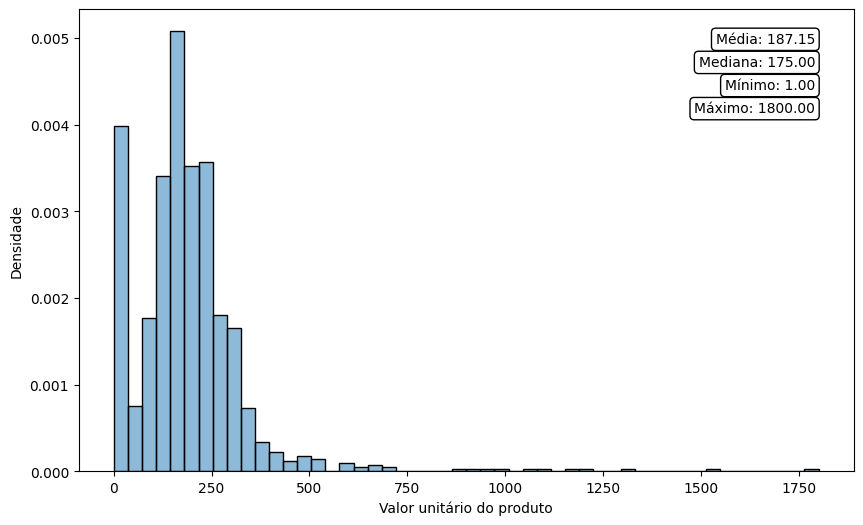

In [45]:
# Histograma dos valores de silenciosos para o banco inteiro.

df_completo_pmpf = df_completo[((df_completo.cest == 1075) | (df_completo.cest == 10750) 
                                | (df_completo.cest == 107500)) & (df_completo.ncm == 87089200)].copy()

media = df_completo_pmpf.vuncom.mean()
mediana = df_completo_pmpf.vuncom.median()
minimo = df_completo_pmpf.vuncom.min()
maximo = df_completo_pmpf.vuncom.max()
plt.figure(figsize = (10, 6))
sns.histplot(data = df_completo_pmpf, x = 'vuncom', bins = 50, alpha = 0.5, stat = 'density')
#plt.title('Histograma do valor unitário do produto')
plt.xlabel('Valor unitário do produto')
plt.ylabel('Densidade')
plt.text(
    0.95, 0.95,
    f'Média: {media:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.9,
    f'Mediana: {mediana:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.85,
    f'Mínimo: {minimo:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.8,
    f'Máximo: {maximo:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.savefig('vuncom_pmpf_todo_banco.png', dpi = 300, format = 'png')
plt.show();

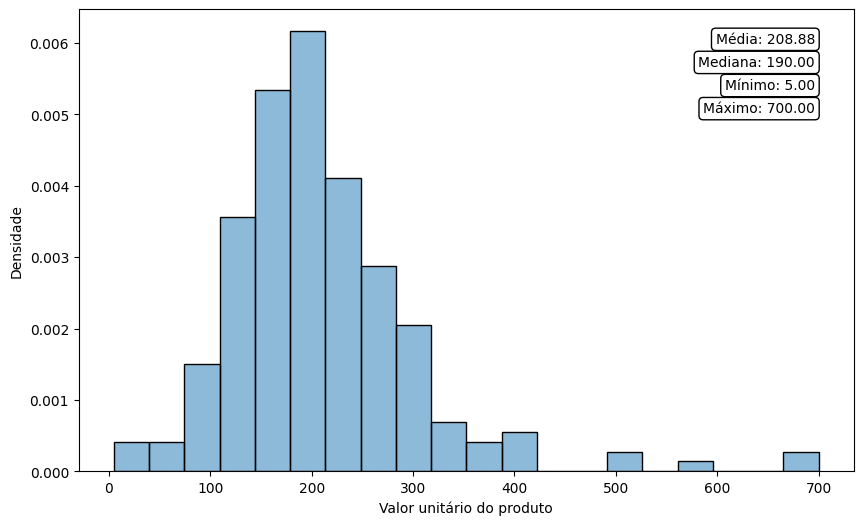

In [46]:
# Histograma dos valores de silenciosos para o cluster 16, que possuem NCM
# de silensioso e tubos de escape (8708.92.00) e CESTs iguais a 1075, 10750 e
# 107500, com 210 itens

df_pmpf = df[(df.clusters == 16) & ((df.cest == 1075) | (df.cest == 10750) 
                          | (df.cest == 107500)) & (df.ncm == 87089200)]

media = df_pmpf.vuncom.mean()
mediana = df_pmpf.vuncom.median()
minimo = df_pmpf.vuncom.min()
maximo = df_pmpf.vuncom.max()
plt.figure(figsize = (10, 6))
sns.histplot(data = df_pmpf, x = 'vuncom', bins = 20, alpha = 0.5, stat = 'density')
#plt.title('Histograma do valor unitário do produto')
plt.xlabel('Valor unitário do produto')
plt.ylabel('Densidade')
plt.text(
    0.95, 0.95,
    f'Média: {media:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.9,
    f'Mediana: {mediana:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.85,
    f'Mínimo: {minimo:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.8,
    f'Máximo: {maximo:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.savefig('vuncom_pmpf_verdadeiro.png', dpi = 300, format = 'png')
plt.show();

In [58]:
# Cálculo do PMPF:

pmpf_real = np.sum(df_pmpf.vuncom * df_pmpf.qcom) / np.sum(df_pmpf.qcom)
pmpf_ficticio = np.sum(df_completo_pmpf.vuncom * df_completo_pmpf.qcom) / np.sum(df_completo_pmpf.qcom)
print(f'PMPF real: R$ {round(pmpf_real, 2)}')
print(f'PMPF fictício: R$ {round(pmpf_ficticio, 2)}')
print(f'O PMPF fictício subfatura o preço de silenciosos em {round(((pmpf_ficticio/pmpf_real)-1)*100*-1, 2)}%')

PMPF real: R$ 203.99
PMPF fictício: R$ 162.49
O PMPF fictício subfatura o preço de silenciosos em 20.35%


In [59]:
sum(df_pmpf.qcom)

219.0

In [61]:
sum(df_completo_pmpf.qcom)

1435.95

# Cálculo da similaridade cosseno entre os clusters:

In [5]:
df_embeddings = pd.DataFrame(X)
df_embeddings['cluster'] = rotulos

# Calcular os Centroides dos Clusters: 
# Agrupar por cluster, calcular a média de cada dimensão do embedding e removemos os outliers:
centroides = df_embeddings[df_embeddings['cluster'] != -1].groupby('cluster').mean()

# Calcular a Matriz de Similaridade Cosseno:
matriz_similaridade = cosine_similarity(centroides)

# Para um gráfico mais informativo, cria-se um DataFrame com os resultados
# usando os IDs dos clusters como índice e colunas:
df_similaridade = pd.DataFrame(
    matriz_similaridade,
    index = centroides.index,
    columns = centroides.index
)

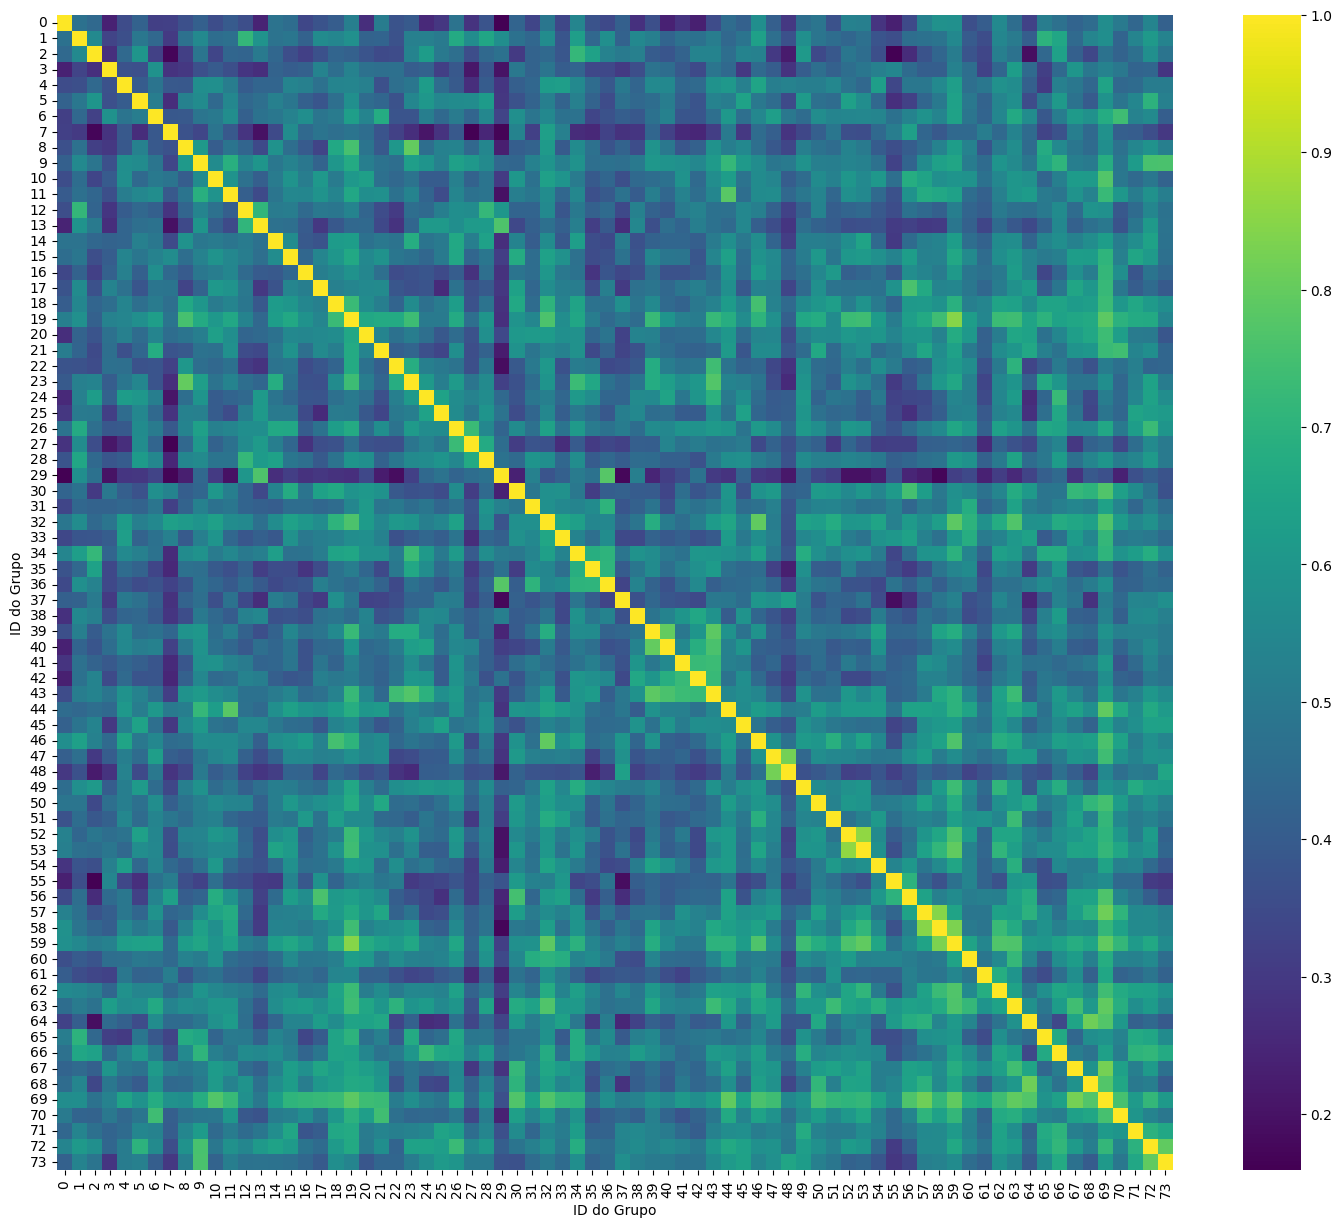

In [49]:
# Geração do Gráfico (Heatmap)
plt.figure(figsize = (18, 15))
sns.heatmap(
    df_similaridade,
    cmap = 'viridis',
    annot = False
)

plt.xlabel('ID do Grupo')
plt.ylabel('ID do Grupo')
plt.savefig('heatmap_similaridade_clusters.png', dpi = 300)
plt.show()

# Calculando a similaridade do cosseno de cada item com cada item do mesmo grupo para ver se faz sentido a coerência temática (tema bem delimitado)

## É possível fazer o acima por meio do cálculo da distância do centroide de cada grupo para cada item daquele grupo (menos poder computacional)

In [24]:
# Cria lista para armazenar os resultados de cada cluster:
resultados_coerencia = []

# Iterar por cada cluster:
for cluster_id in centroides.index:
    
    # Isolar o centroide do cluster atual e garantir que ele tenha o formato correto (1, n_features):
    centroide_atual = centroides.loc[cluster_id].values.reshape(1, -1)
    
    # Isolar os embeddings de todos os itens que pertencem a este cluster:
    embeddings_do_cluster = df_embeddings[df_embeddings['cluster'] == cluster_id].drop('cluster', axis = 1).values
    
    # Calcular a similaridade de cosseno de cada item com o centroide do seu próprio cluster:
    similaridades = cosine_similarity(embeddings_do_cluster, centroide_atual)
    
    # Calcular as métricas de resumo para este cluster:
    coerencia_media = np.mean(similaridades)
    coerencia_minima = np.min(similaridades)
    desvio_padrao = np.std(similaridades)
    qtd_itens = len(embeddings_do_cluster)
    
    # Armazenar os resultados:
    resultados_coerencia.append({
        'cluster': cluster_id,
        'qtd_itens': qtd_itens,
        'coerencia_media': coerencia_media,
        'coerencia_minima': coerencia_minima,
        'desvio_padrao_similaridade': desvio_padrao
    })

# Cria um DataFrame com os resultados:
df_coerencia = pd.DataFrame(resultados_coerencia)

In [43]:
df_coerencia.to_csv('analise_coerencia_por_similaridade.csv')

In [65]:
tipo_agrupamento = ['Funcional forte',
'Funcional forte',
'Por tipo de peça',
'Aplicação em veículo',
'Por tipo de peça',
'Tema Duplo/Bitemático',
'Aplicação em veículo',
'Aplicação em veículo',
'Funcional forte',
'Funcional forte',
'Funcional forte',
'Funcional forte',
'Tema Duplo/Bitemático',
'Divisão de tema',
'Por tipo de peça',
'Funcional forte',
'Funcional forte',
'Funcional forte',
'Por tipo de peça',
'Residual',
'Funcional forte',
'Por tipo de peça',
'Funcional forte',
'Funcional forte',
'Funcional forte',
'Funcional forte',
'Por material/aparência',
'Aplicação em veículo',
'Aplicação em veículo',
'Divisão de tema',
'Aplicação em veículo',
'Aplicação em veículo',
'Aplicação em veículo',
'Funcional forte',
'Por tipo de peça',
'Funcional forte',
'Funcional forte',
'Por tipo de peça',
'Funcional forte',
'Aplicação em veículo',
'Residual',
'Funcional forte',
'Tema Duplo/Bitemático',
'Residual',
'Residual',
'Funcional forte',
'Por tipo de peça',
'Divisão de tema',
'Divisão de tema',
'Divisão de tema',
'Divisão de tema',
'Funcional forte',
'Funcional forte',
'Residual',
'Aplicação em veículo',
'Aplicação em veículo',
'Aplicação em veículo',
'Divisão de tema',
'Divisão de tema',
'Residual',
'Aplicação em veículo',
'Funcional forte',
'Por tipo de peça',
'Aplicação em veículo',
'Tema Duplo/Bitemático',
'Por material/aparência',
'Por tipo de peça',
'Aplicação em veículo',
'Aplicação em veículo',
'Residual',
'Por tipo de peça',
'Por tipo de peça',
'Residual',
'Tema Duplo/Bitemático']
df_coerencia['tipo_agrupamento'] = tipo_agrupamento
df_coerencia.rename(columns = {'tipo_agrupamento':'Tipo de Agrupamento'}, inplace = True)

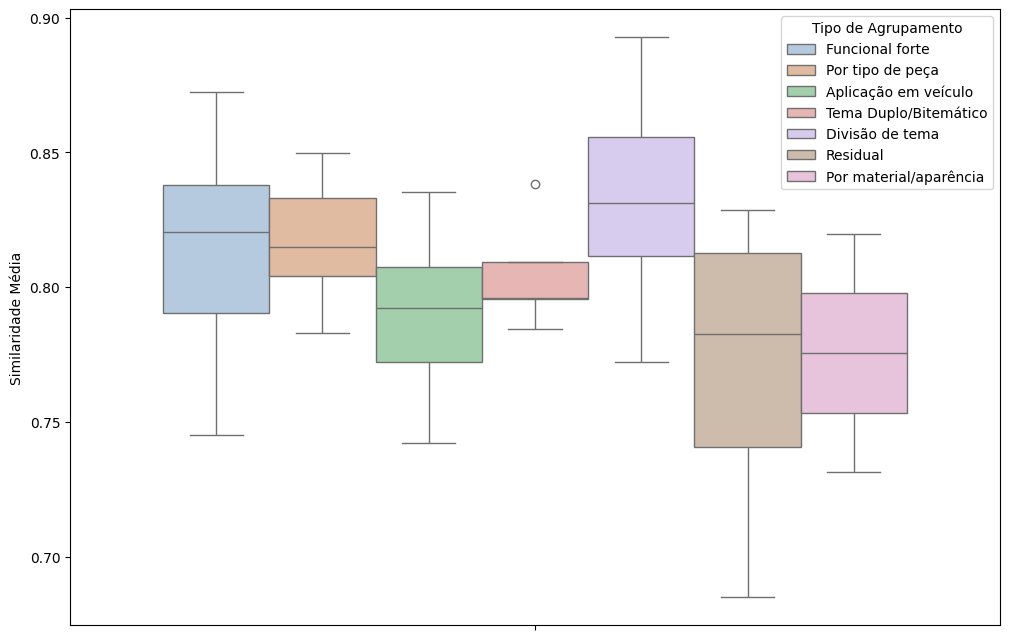

In [84]:
plt.figure(figsize = (12, 8))
sns.boxplot(data = df_coerencia, y = 'coerencia_media', hue = 'Tipo de Agrupamento', palette = 'pastel', saturation = 0.5)
plt.ylabel('Similaridade Média')
plt.savefig('boxplot_similaridade_por_tipo.png', dpi = 300)
plt.show();

# Encontrar no banco inteiro os silenciosos:

In [5]:
df_embeddings = pd.DataFrame(X)
df_embeddings['cluster'] = rotulos

# Calcular os Centroides dos Clusters: 
# Agrupar por cluster, calcular a média de cada dimensão do embedding e removemos os outliers:
centroides = df_embeddings[(df_embeddings['cluster'] != -1) & (df_embeddings['cluster'] == 16)].groupby('cluster').mean()

In [8]:
centroides

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
cluster,,,,,,,,,,,,,,,,,,,,,
16,0.096564,0.161167,-0.034917,-0.004579,0.025676,-0.005422,0.047669,0.059802,-0.01614,-0.114773,...,0.099261,-0.022026,0.063764,0.062038,-0.217147,0.016523,0.079349,0.111153,0.024216,0.110775


In [36]:
caminho_banco_completo = 'embeddings_parquet_multilingual/embedding_T4_8708_todo_banco.parquet'
colunas_para_ler = ['idx', 'embedding_T4']
batch_size = 50000  # Processa 50.000 itens de cada vez. Pode ajustar conforme a memória.

# Lista para armazenar os resultados de cada lote
resultados_parciais = []

try:
    parquet_file = pq.ParquetFile(caminho_banco_completo)
    
    for i, batch in enumerate(parquet_file.iter_batches(batch_size=batch_size, columns=colunas_para_ler)):
        batch_df = batch.to_pandas()
        
        # Prepara a matriz de embeddings do lote
        embeddings_lote = np.vstack(batch_df['embedding_T4'].apply(np.array)).astype(np.float32)
        
        # Calcula a similaridade de cosseno do lote com o centroide do Cluster 16
        similaridades = cosine_similarity(embeddings_lote, centroides)
        
        # Armazena os resultados (idx e similaridade)
        resultados_lote_df = pd.DataFrame({
            'idx': batch_df['idx'],
            'similaridade': similaridades.flatten()
        })
        
        resultados_parciais.append(resultados_lote_df)

    # --- PASSO 3: Consolidar e Apresentar os Resultados Finais ---
    
    # Junta os resultados de todos os lotes em um único DataFrame
    df_resultados_finais = pd.concat(resultados_parciais, ignore_index=True)
    
    # Ordena para encontrar os itens mais similares
    df_resultados_finais_sorted = df_resultados_finais.sort_values(by='similaridade', ascending=False)
    
    # Imprime os 20 melhores resultados
    print(df_resultados_finais_sorted.head(20).to_string(index=False))

except FileNotFoundError:
    print(f"\nERRO: O arquivo não foi encontrado em '{caminho_banco_completo}'. Verifique o caminho.")
except Exception as e:
    print(f"\nOcorreu um erro inesperado: {e}")

    idx  similaridade
1444836      0.975208
3194705      0.972752
 846922      0.971035
1562273      0.967538
3442531      0.967054
1754609      0.966896
 538902      0.965636
2103040      0.965465
2554730      0.965465
2034882      0.965465
 776650      0.965465
2246417      0.965465
1415894      0.965465
 836123      0.965465
1302016      0.964071
2235896      0.964071
 915485      0.964071
1601846      0.964071
 730127      0.964071
1711687      0.964071


In [23]:
df_completo = pd.read_csv('NFCE_OUT24_A_DEZ24_8708.csv', sep = ';', encoding = 'latin1')
df_completo = df_completo.rename(columns = {i:i.lower() for i in list(df_completo.columns)})

In [26]:
# Top 20 similaridade cosseno:

indices_para_buscar = [
    1444836, 3194705, 846922, 1562273, 3442531, 1754609, 538902,
    2103040, 2554730, 2034882, 776650, 2246417, 1415894, 836123,
    1302016, 2235896, 915485, 1601846, 730127, 1711687
]

for i in indices_para_buscar:
    print(df_completo.xprod.iloc[i])

SILENCIOSO PEUGEOT 206 1.6 8V TRAS 1078337
SILENCIOSO MERCEDES C/ ABRACADEIRA 43-191
SILENCIOSO INTER PICASSO
3012-0-SILENCIOSO INTERME FIEST
SILENCIOSO TR STILO 1.8 02/ *
#0107500#S 11099 SILENCIOSO INTERM.POLO 1.6/1.8 9
SILENCIOSO INTER CITROEN PICASSO 2,0 16
SILENCIOSO INTER. SICAP S-10150.
SILENCIOSO INTER. SICAP S-11171
SILENCIOSO INTER. SICAP S- 10735.
SILENCIOSO INTER. SICAP S-11171
SILENCIOSO INTER. SICAP S-10190.
SILENCIOSO INTER.SICAP S-121.(10509)
SILENCIOSO INTER. SICAP S- 10735.
SILENCIOSO SICAP S-11150
SILENCIOSO SICAP S-11548/8097
SILENCIOSO SICAP S-360
SILENCIOSO SICAP S-11171
SILENCIOSO SICAP S10615
SILENCIOSO SICAP S-11172/5143


In [38]:
indices_para_buscar = list(df_resultados_finais_sorted[df_resultados_finais_sorted.similaridade >= 0.96].idx)

for i in indices_para_buscar:
    print(df_completo.xprod.iloc[i])

SILENCIOSO PEUGEOT 206 1.6 8V TRAS 1078337
SILENCIOSO MERCEDES C/ ABRACADEIRA 43-191
SILENCIOSO INTER PICASSO
3012-0-SILENCIOSO INTERME FIEST
SILENCIOSO TR STILO 1.8 02/ *
#0107500#S 11099 SILENCIOSO INTERM.POLO 1.6/1.8 9
SILENCIOSO INTER CITROEN PICASSO 2,0 16
SILENCIOSO INTER. SICAP S-10150.
SILENCIOSO INTER. SICAP S-11171
SILENCIOSO INTER. SICAP S- 10735.
SILENCIOSO INTER. SICAP S-11171
SILENCIOSO INTER. SICAP S-10190.
SILENCIOSO INTER.SICAP S-121.(10509)
SILENCIOSO INTER. SICAP S- 10735.
SILENCIOSO SICAP S-11150
SILENCIOSO SICAP S-11548/8097
SILENCIOSO SICAP S-360
SILENCIOSO SICAP S-11171
SILENCIOSO SICAP S10615
SILENCIOSO SICAP S-11172/5143
SILENCIOSO SICAP S-11547
SILENCIOSO SICAP S-123/7401
SILENCIOSO SICAP S-11664
SILENCIOSO SICAP S-11548/8097
SILENCIOSO SICAP S-11172/5143
SILENCIOSO SICAP S-11773
SILENCIOSO SICAP S-11548/8097
SILENCIOSO TRASS KADET
S279 CONJ SILENCIOSO
SILENCIOSO INTER. PALIO 1.0 97...
SILENCIOSO INTER. PALIO 1.0 97...
SILENCIOSO INTER. PALIO 1.0 97...
SILENCI